In [ ]:
from binance.client import Client
from binance.enums import *
import pandas as pd
import os
import time
import numpy as np
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import seaborn as sns
from scipy import stats
import ta

from Backtest import *

API_KEY = "secreta" 
API_SECRET = "confidencial"
client = Client(API_KEY,API_SECRET, tld = "com")

In [53]:
ticket = 'ETHUSDT'
#['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT',"DOTUSDT","EGLDUSDT","ETCUSDT","DOGEUSDT"]
# LTCUSDT , TRXUSDT , LINKUSDT , XLMUSDT , ATOMUSDT , IOTAUSDT ALGOUSDT COMPUSDT BALUSDT, "PEPEUSDT"
df= load_binance_ohlcv(ticket,interval= Client.KLINE_INTERVAL_30MINUTE,start_str= '1 Jan, 2025',end_str = None)#"30 Dec, 2024" #None #5M

Descargando datos de ETHUSDT desde 1 Jan, 2025 hasta ahora con intervalo 30m...


In [54]:
def preparar_datos(df, bb_window=20, bb_std_dev=2, ema_period=200, adx_window=14,rsi_period=14):
    """
    Prepara los datos para la estrategia de Bandas de Bollinger con filtros EMA 200 y ADX
    
    Parámetros:
    - bb_window: Período para las Bandas de Bollinger (default 20)
    - bb_std_dev: Desviación estándar (default 2)
    - ema_period: Período de la EMA (default 200)
    - adx_window: Período del ADX (default 14)
    """
    df = df.copy()
    df.columns = [col.lower() for col in df.columns]
    
    # 1. Bandas de Bollinger
    df['bb_ma'] = df['close'].rolling(window=bb_window).mean()
    df['bb_upper'] = df['bb_ma'] + (df['close'].rolling(window=bb_window).std() * bb_std_dev)
    df['bb_lower'] = df['bb_ma'] - (df['close'].rolling(window=bb_window).std() * bb_std_dev)
    
    # 2. EMA de tendencia
    df['ema_confirm'] = df['close'].ewm(span=ema_period, adjust=False).mean()
    
    # 3. ADX para fuerza de tendencia
    adx_ind = ta.trend.ADXIndicator(df['high'], df['low'], df['close'], window=adx_window)
    df['adx'] = adx_ind.adx()
    df['+di'] = adx_ind.adx_pos()
    df['-di'] = adx_ind.adx_neg()
    # 4. RSI (nuevo)
    df['rsi'] = ta.momentum.RSIIndicator(df['close'], window=rsi_period).rsi()
    
    return df.dropna()

# Ejemplo de uso:
df = preparar_datos(df)
df.tail()

,open,high,low,close,volume,bb_ma,bb_upper,bb_lower,ema_confirm,adx,+di,-di,rsi
datetime,,,,,,,,,,,,,
2026-04-10 00:30:00,2189.83,2197.39,2187.67,2195.17,3138.0819,2206.8230,2229.610138,2184.035862,2165.618541,22.558026,27.101771,18.735262,47.198279
2026-04-10 01:00:00,2195.17,2197.03,2176.10,2186.31,6264.6461,2206.9085,2229.354834,2184.462166,2165.824426,21.308866,24.547887,22.178938,42.626604
2026-04-10 01:30:00,2186.31,2204.10,2184.79,2194.70,6693.7661,2205.7440,2228.186238,2183.301762,2166.111745,20.612380,25.580813,20.280167,47.784381
2026-04-10 02:00:00,2194.69,2198.62,2192.48,2196.20,1951.7522,2205.0685,2227.819275,2182.317725,2166.411131,19.965644,24.852247,19.702569,48.672791
2026-04-10 02:30:00,2196.21,2197.47,2193.00,2193.68,1507.1981,2204.3360,2227.582591,2181.089409,2166.682463,19.365103,24.309431,19.272231,47.219254


In [55]:
def signal(df, adx_threshold=25):
    """
    Genera señales con filtros de tendencia y fuerza
    
    Reglas:
    - Compra: Cierre sobre banda inferior Y precio < EMA 200 Y ADX > umbral
    - Venta: Cierre bajo banda superior Y precio  > EMA 200 Y ADX > umbral
    """
    signals = pd.Series(0, index=df.index)
    
    # Condición VENTA
    sell_condition = (
        (df['close'] > df['bb_upper']) & 
        (df['close'] <df['ema_confirm']) &
        (df['adx'] > adx_threshold) #&
        #(df['+di'] < df['-di'])
    )
    
    # Condición COMPRA
    buy_condition = (
        (df['close'] < df['bb_lower']) & 
        (df['close'] > df['ema_confirm']) &
        (df['adx'] > adx_threshold) #&
        #(df['-di'] < df['+di'])
    )
    
    signals[buy_condition] = 1
    signals[sell_condition] = -1
    
    # Eliminar señales consecutivas (esperar nuevo breakout)
    signals = signals.replace(0, method='ffill', limit=1)
    df['signal'] = signals
    
    # Estadísticas
    print(f"Señales compra: {sum(signals == 1)} | Señales venta: {sum(signals == -1)}")
    print(f"Fuerza media ADX en señales: {df[signals != 0]['adx'].mean():.1f}")
    
    return df

# Uso completo:
signal_df = signal(df)
signal_df.tail(3)

Señales compra: 203 | Señales venta: 199
Fuerza media ADX en señales: 31.8


,open,high,low,close,volume,bb_ma,bb_upper,bb_lower,ema_confirm,adx,+di,-di,rsi,signal
datetime,,,,,,,,,,,,,,
2026-04-10 01:30:00,2186.31,2204.10,2184.79,2194.70,6693.7661,2205.7440,2228.186238,2183.301762,2166.111745,20.612380,25.580813,20.280167,47.784381,0
2026-04-10 02:00:00,2194.69,2198.62,2192.48,2196.20,1951.7522,2205.0685,2227.819275,2182.317725,2166.411131,19.965644,24.852247,19.702569,48.672791,0
2026-04-10 02:30:00,2196.21,2197.47,2193.00,2193.68,1507.1981,2204.3360,2227.582591,2181.089409,2166.682463,19.365103,24.309431,19.272231,47.219254,0


In [56]:
"""# Incluye el índice en el CSV
df.to_csv('mi_dataframe.csv', index=True, encoding='utf-8')

# O con punto y coma
df.to_csv('mi_dataframe.csv', index=True, sep=';', encoding='utf-8')"""

"# Incluye el índice en el CSV\ndf.to_csv('mi_dataframe.csv', index=True, encoding='utf-8')\n\n# O con punto y coma\ndf.to_csv('mi_dataframe.csv', index=True, sep=';', encoding='utf-8')"

In [57]:
def run_tp_sl_daily(data, apalancamiento=1, tp=0.03, sl=-0.010, cost=0.0004):
    trades = []
    in_position = False
    entry_price = 0
    entry_index = None
    direction = 0  # 1 = long, -1 = short
    last_trade_date = None  # Para trackear la última fecha de operación

    for i in range(len(data)):
        row = data.iloc[i]
        price = row['close']
        signal = row['signal']
        current_date = row.name.date() if hasattr(row.name, 'date') else row.name  # Obtener fecha

        # Verificar si ya operamos hoy
        already_traded_today = last_trade_date == current_date

        # Abrir operación (solo si no hay posición y no hemos operado hoy)
        if not in_position and signal != 0 and not already_traded_today:
            in_position = True
            entry_price = price
            entry_index = data.index[i]
            direction = signal
            continue

        # Cierre por SL / TP / cambio de señal opuesta
        if in_position:
            pct_change = (price - entry_price) / entry_price * direction
            close_trade = False

            # Cerrar por TP/SL
            if pct_change >= tp or pct_change <= sl:
                close_trade = True

            # O cerrar si la señal cambia en dirección opuesta
            elif signal == -direction and signal != 0:
                close_trade = True

            if close_trade:
                exit_index = data.index[i]
                net_return = (pct_change - cost) * apalancamiento

                trades.append({
                    'entry_time': entry_index,
                    'exit_time': exit_index,
                    'entry_price': entry_price,
                    'exit_price': price,
                    'direction': direction,
                    'pct_change': pct_change,
                    'net_return': net_return
                })

                # Reset posición y guardar fecha de última operación
                in_position = False
                entry_price = 0
                entry_index = None
                direction = 0
                last_trade_date = current_date  # Actualizar última fecha de operación

    return pd.DataFrame(trades)

In [58]:
returns_df = run_tp_sl_daily(signal_df,apalancamiento=1, tp=0.025, sl=-0.010,cost=0.0004) #.022 - -0.01
df_m = calcular_rendimiento_acumulado(returns_df)
metricas = evaluar_metricas(returns_df, risk_free_rate=0.00)
print(metricas)

{'win_rate': 0.37, 'sharpe_ratio': 1.7, 'max_drawdown': -0.11, 'total_trades': 109, 'total_return': 0.22}


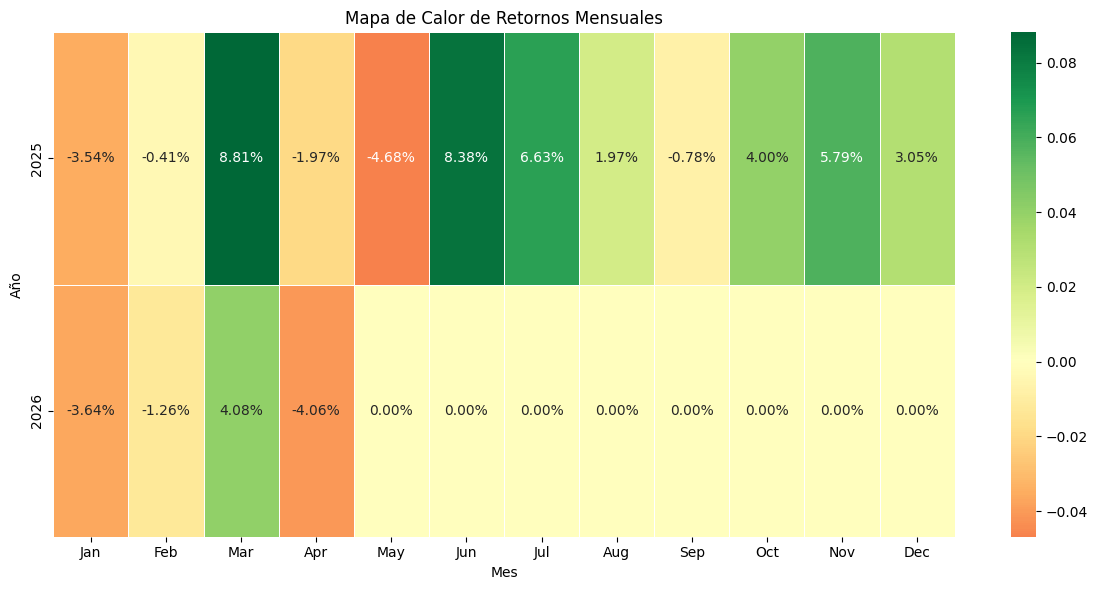

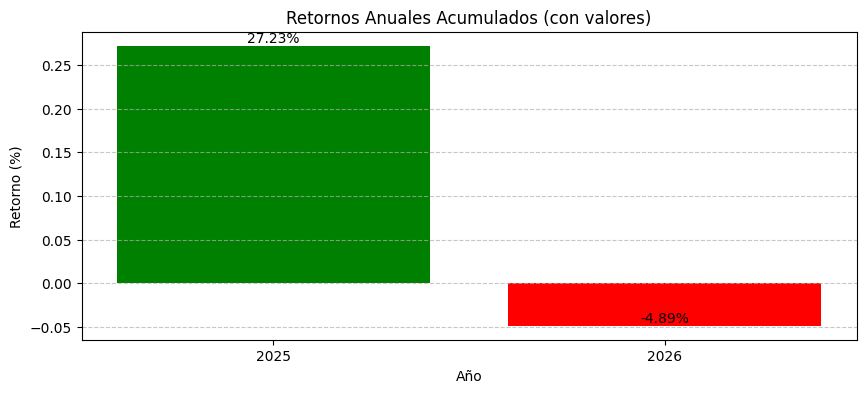

In [59]:
heatmap_monthly_returns(returns_df)
plot_annual_returns(returns_df)

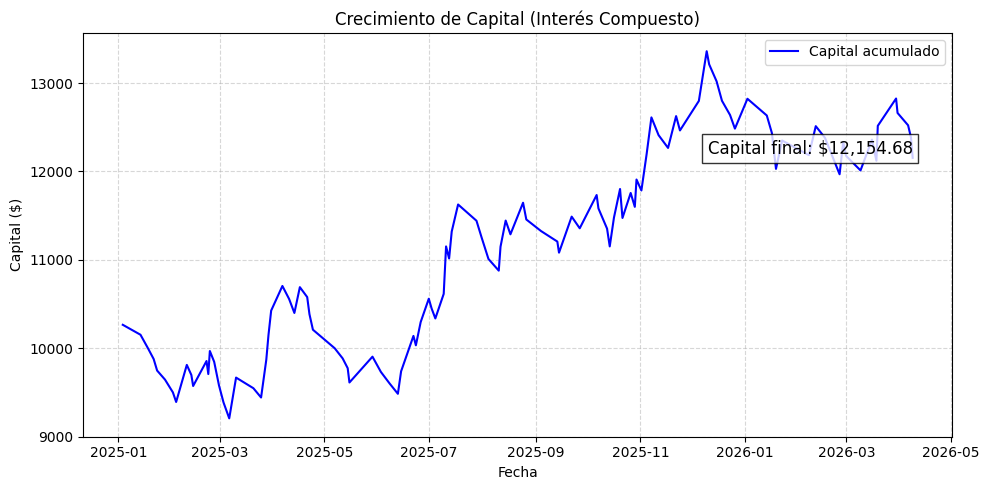

In [60]:
capital_simulation = simulate_compounded_growth(returns_df)
plt.figure(figsize=(10, 5))
plt.plot(capital_simulation['exit_time'], capital_simulation['capital'], 
         marker='', linestyle='-', color='blue', label='Capital acumulado')
final_capital = capital_simulation['capital'].iloc[-1]
plt.text(
    capital_simulation['exit_time'].iloc[-1], 
    final_capital, 
    f'Capital final: ${final_capital:,.2f}', 
    ha='right', va='bottom', 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.8)
)
plt.title("Crecimiento de Capital (Interés Compuesto)")
plt.xlabel("Fecha")
plt.ylabel("Capital ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()